In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    roc_auc_score,
    roc_curve,
    classification_report,
    confusion_matrix
)

In [3]:
df = pd.read_csv("/content/sample_data/hospital_readmission_risk_dataset_2026_v1_18000rows (1).csv")

print("First 5 rows:")
print(df.head())

print("\nDataset information:")
print(df.info())

First 5 rows:
   Age  Gender Insurance_Type  Socioeconomic_Risk_Score  \
0   71    Male       Medicare                         9   
1   34  Female        Private                         8   
2   80    Male       Medicare                         2   
3   40  Female        Private                         7   
4   43    Male       Medicaid                         5   

   Previous_Admissions_6M  Previous_Readmissions_1Y  \
0                       2                         0   
1                       4                         0   
2                       1                         3   
3                       2                         0   
4                       2                         1   

   Time_Since_Last_Discharge  Length_of_Stay Admission_Type  \
0                         96              15         Urgent   
1                         58              12         Urgent   
2                         25              11         Urgent   
3                         42               2    

In [11]:
df = df.dropna()


In [14]:
X = df.drop(columns=["Readmitted_Within_30_Days"])
y = df["Readmitted_Within_30_Days"]


In [15]:
numeric_features = [
    "Age",
    "Socioeconomic_Risk_Score",
    "Previous_Admissions_6M",
    "Previous_Readmissions_1Y",
    "Time_Since_Last_Discharge",
    "Length_of_Stay",
    "Comorbidity_Index",
    "Chronic_Disease_Count",
    "ICU_Stay_Flag",
    "Severity_Score",
    "HbA1c_Level",
    "Creatinine_Level",
    "Hemoglobin_Level",
    "Average_Systolic_BP",
    "Number_of_Medications",
    "Medication_Change_Count",
    "High_Risk_Medication_Flag",
    "Followup_Appointment_Scheduled",
    "Medication_Adherence_Score"
]

categorical_features = [
    "Gender",
    "Insurance_Type",
    "Admission_Type",
    "Primary_Diagnosis_Group",
    "Discharge_Disposition"
]

In [16]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        (
            "cat",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features
        )
    ]
)

In [18]:
model = Pipeline([
    ("preprocessor", preprocessor),
    (
        "classifier",
        LogisticRegression(
            penalty="l2",
            C=1.0,
            solver="lbfgs",
            max_iter=1000
        )
    )
])

# Train the model
model.fit(X_train, y_train)

print("Model training completed!")

Model training completed!


In [19]:
# Predict readmission probabilities
y_prob = model.predict_proba(X_test)[:, 1]

# Convert probabilities into classes
y_pred = (y_prob >= 0.5).astype(int)

# ROC-AUC
auc = roc_auc_score(y_test, y_prob)

print("ROC-AUC Score:", round(auc, 4))

# Classification report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Confusion matrix
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

ROC-AUC Score: 0.5667

Classification Report:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00       930
           1       0.74      1.00      0.85      2670

    accuracy                           0.74      3600
   macro avg       0.37      0.50      0.43      3600
weighted avg       0.55      0.74      0.63      3600


Confusion Matrix:
[[   0  930]
 [   0 2670]]


/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


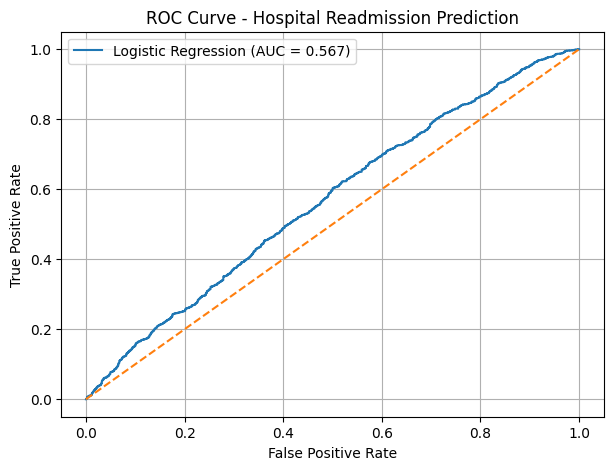

In [20]:
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.figure(figsize=(7, 5))

plt.plot(
    fpr,
    tpr,
    label=f"Logistic Regression (AUC = {auc:.3f})"
)

plt.plot([0, 1], [0, 1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Hospital Readmission Prediction")
plt.legend()
plt.grid(True)
plt.show()